# minimal-linop 3/3: Benchmark

*What the abstraction costs: the overhead against hand-written torch, `LinOpPatch` against `LinOpCrop @ LinOpRoll`, batching, `to_matrix`, precision — and when not to use any of it.*

Series: [1. Why](01_why_linear_operators.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from minimal_linop import (LinOpIdentity, LinOpFft, LinOpMul, LinOpCrop, LinOpRoll,
                           LinOpPatch, LinOpCat, adjoint_error, operator_norm, to_matrix)

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]),
    "image.cmap": "gray",
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.0


Every timing below comes from one machine, one process, possibly with two sibling notebooks running beside it. Treat them as indicative of this machine and of the *shape* of the scaling, not as portable constants.

In [2]:
import os, platform

print(f"processor       {platform.processor()} / {platform.machine()}")
print(f"logical cores   {os.cpu_count()}")
print(f"torch threads   {torch.get_num_threads()}")
print(f"MPS available   {torch.backends.mps.is_available()}")
print("\nTimings are indicative for this machine only.")

processor       arm / arm64
logical cores   8
torch threads   4
MPS available   True

Timings are indicative for this machine only.


## Timing protocol

`bench` makes one warm-up call — paying for the allocations, the FFT plan cache and, for `LinOpPatch`, the one-off construction of its index tables — then `repeats` timed calls, and returns the **median**. Calls on MPS are asynchronous, so they are bracketed with `torch.mps.synchronize()`.

Colours are fixed throughout: blue = hand-written `torch`, orange = the operator, aqua = the cheaper of two operators being compared, yellow = MPS.

In [3]:
BLUE, ORANGE, AQUA, YELLOW, PINK = plt.rcParams["axes.prop_cycle"].by_key()["color"]
C64, C128 = torch.complex64, torch.complex128


def bench(fn, repeats=7):
    """One warm-up call, then `repeats` timed calls; the median, in seconds."""
    out = fn()
    on_mps = torch.is_tensor(out) and out.device.type == "mps"
    if on_mps:
        torch.mps.synchronize()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        if on_mps:
            torch.mps.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


z256 = torch.randn(256, 256, dtype=C64)
print(f"bench(lambda: torch.fft.fft2(z256)) = {1e6 * bench(lambda: torch.fft.fft2(z256)):.1f} us"
      f"   [{z256.shape[0]}x{z256.shape[1]} complex64, the unit of comparison below]")

bench(lambda: torch.fft.fft2(z256)) = 157.1 us   [256x256 complex64, the unit of comparison below]


# Part A — What the algebra costs

## A.1 A composed operator against the same lines written by hand

The forward model of notebook 1, for one scan position:

$$A x = \mathcal{F}\big[\, p \odot (\text{window of } x)\,\big] \qquad\text{i.e.}\qquad
\texttt{LinOpFft(dim=(-2,-1)) @ LinOpMul(probe) @ LinOpPatch(...)}$$

against a hand-written function that does exactly the same three things with `torch` calls and precomputed indices. Any difference is the price of the abstraction: three Python method calls and two attribute lookups per application.

In [4]:
PATCH = 32
probe = torch.randn(PATCH, PATCH, dtype=C64)
sizes_ov = [64, 128, 256, 512, 1024, 2048]
t_op, t_hand, t_opT, t_handT = [], [], [], []

print(f"{'object':>10} {'apply (op)':>13} {'apply (hand)':>15} {'applyT (op)':>14} "
      f"{'applyT (hand)':>16}")
for n in sizes_ov:
    x, y = torch.randn(n, n, dtype=C64), torch.randn(PATCH, PATCH, dtype=C64)
    A = LinOpFft(dim=(-2, -1)) @ LinOpMul(probe) @ LinOpPatch((n, n), (PATCH, PATCH), shifts=(5, -7))

    start = n // 2 - PATCH // 2                       # the same window, precomputed
    iy = torch.remainder(torch.arange(start, start + PATCH) - 5, n)[:, None]
    ix = torch.remainder(torch.arange(start, start + PATCH) + 7, n)[None, :]
    flat = (iy * n + ix).reshape(-1)

    def hand(x=x, iy=iy, ix=ix):
        return torch.fft.fft2(probe * x[..., iy, ix], norm="ortho")

    def handT(y=y, flat=flat, n=n):
        v = probe.conj() * torch.fft.ifft2(y, norm="ortho")
        return torch.zeros(n * n, dtype=C64).scatter_add(-1, flat, v.reshape(-1)).reshape(n, n)

    assert torch.allclose(A.apply(x), hand(), atol=1e-5)
    assert torch.allclose(A.applyT(y), handT(), atol=1e-5)
    # Two benches, faster kept: the adjoints allocate an object-sized tensor
    # every call, and whichever contender runs first pays for the fresh pages.
    fair = lambda f: min(bench(f), bench(f))
    t_op.append(fair(lambda: A.apply(x)))
    t_hand.append(fair(hand))
    t_opT.append(fair(lambda: A.applyT(y)))
    t_handT.append(fair(handT))
    print(f"{f'{n}x{n}':>10} {1e6*t_op[-1]:>10.1f} us {1e6*t_hand[-1]:>12.1f} us "
          f"{1e6*t_opT[-1]:>11.1f} us {1e6*t_handT[-1]:>13.1f} us")

    object    apply (op)    apply (hand)    applyT (op)    applyT (hand)
     64x64        9.8 us          9.1 us        16.5 us          11.0 us
   128x128        9.5 us          8.9 us        18.1 us          12.6 us
   256x256       10.3 us          9.2 us        38.3 us          29.5 us
   512x512       10.2 us          9.3 us       146.4 us         141.7 us
 1024x1024        9.7 us          9.0 us       809.7 us        1094.3 us


 2048x2048        9.7 us          9.0 us      2437.2 us        2198.5 us


The overhead of a chain does not depend on the size of the data, so it is worth measuring on its own: a chain of $k$ `LinOpIdentity` operators applied to a single number is pure dispatch.

 nodes       time
     1    0.08 us
     2    0.17 us
     4    0.25 us
     8    0.42 us
    16    0.71 us
    32    1.21 us

marginal cost of one more operator in a chain: 36 ns


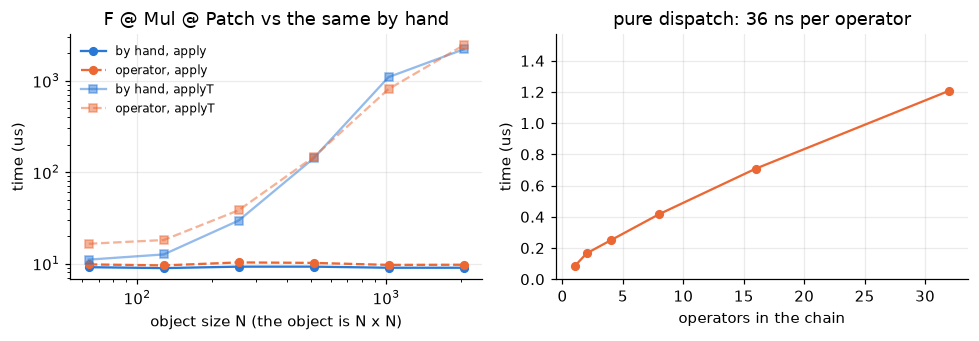

In [5]:
depths = [1, 2, 4, 8, 16, 32]
t_chain = []
one = torch.zeros(1)
for k in depths:
    chain = LinOpIdentity()
    for _ in range(k - 1):
        chain = chain @ LinOpIdentity()
    t_chain.append(bench(lambda: chain.apply(one), repeats=31))
per_node = 1e9 * (t_chain[-1] - t_chain[0]) / (depths[-1] - depths[0])
print(f"{'nodes':>6} {'time':>10}")
for k, t in zip(depths, t_chain):
    print(f"{k:>6} {1e6*t:>7.2f} us")
print(f"\nmarginal cost of one more operator in a chain: {per_node:.0f} ns")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax.loglog(sizes_ov, 1e6 * np.array(t_hand), "o-", ms=5, color=BLUE, label="by hand, apply")
ax.loglog(sizes_ov, 1e6 * np.array(t_op), "o--", ms=5, color=ORANGE, label="operator, apply")
ax.loglog(sizes_ov, 1e6 * np.array(t_handT), "s-", ms=5, color=BLUE, alpha=0.5, label="by hand, applyT")
ax.loglog(sizes_ov, 1e6 * np.array(t_opT), "s--", ms=5, color=ORANGE, alpha=0.5, label="operator, applyT")
ax.set(xlabel="object size N (the object is N x N)", ylabel="time (us)",
       title="F @ Mul @ Patch vs the same by hand")
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax2.plot(depths, 1e6 * np.array(t_chain), "o-", ms=5, color=ORANGE)
ax2.set(xlabel="operators in the chain", ylabel="time (us)",
        title=f"pure dispatch: {per_node:.0f} ns per operator", ylim=(0, 1.3 * 1e6 * max(t_chain)))
fig.tight_layout()
plt.show()

The forward curves lie on top of each other. From $64^2$ to $2048^2$ the composed operator costs about one microsecond more than the hand-written function — three method calls, a few attribute lookups and one dict lookup for `LinOpPatch`'s cached index tables — and that microsecond does not grow with the data, because both end up in the same three `torch` kernels. The adjoints carry a constant offset of a few microseconds at small sizes and are indistinguishable beyond $512^2$, where allocating and zeroing the object-sized output dominates both and varies by tens of percent from run to run.

The marginal cost of one more operator in a chain is a few tens of nanoseconds. That is invisible unless the arrays are small enough that the kernels themselves take a microsecond, which is what C.1 measures.

## A.2 `LinOpPatch` against `LinOpCrop @ LinOpRoll`

`LinOpPatch(in_shape, out_shape, shifts)` is *defined* as `LinOpCrop @ LinOpRoll` — notebook 2 checks that they agree bit for bit — but it gathers the window directly instead of rolling the whole object first. The forward direction is then O(patch) whatever the object size; the adjoint still has to return an object-sized tensor, so it cannot beat O(object), but it writes only the patch into it.

In [6]:
sizes_p = [64, 128, 256, 512, 1024, 2048, 4096]
t_patch, t_roll, t_patchT, t_rollT = [], [], [], []
print(f"{'object':>11} {'patch.apply':>13} {'crop@roll':>12} {'speed-up':>9} "
      f"{'patch.applyT':>14} {'crop@roll':>12} {'speed-up':>9}")
for n in sizes_p:
    x, y = torch.randn(n, n, dtype=C64), torch.randn(PATCH, PATCH, dtype=C64)
    fast = LinOpPatch((n, n), (PATCH, PATCH), shifts=(5, -7))
    slow = LinOpCrop((n, n), (PATCH, PATCH)) @ LinOpRoll((5, -7), dim=(-2, -1))
    reps = 7 if n <= 1024 else 3
    t_patch.append(bench(lambda: fast.apply(x), reps))
    t_roll.append(bench(lambda: slow.apply(x), reps))
    t_patchT.append(bench(lambda: fast.applyT(y), reps))
    t_rollT.append(bench(lambda: slow.applyT(y), reps))
    print(f"{f'{n}x{n}':>11} {1e6*t_patch[-1]:>10.1f} us {1e6*t_roll[-1]:>9.1f} us "
          f"{t_roll[-1]/t_patch[-1]:>9.1f} {1e6*t_patchT[-1]:>11.1f} us "
          f"{1e6*t_rollT[-1]:>9.1f} us {t_rollT[-1]/t_patchT[-1]:>9.1f}")

     object   patch.apply    crop@roll  speed-up   patch.applyT    crop@roll  speed-up
      64x64        5.0 us       8.7 us       1.7        10.0 us      13.9 us       1.4
    128x128        4.8 us      11.4 us       2.4        12.6 us      18.7 us       1.5
    256x256        4.8 us      34.8 us       7.2        59.8 us      55.5 us       0.9
    512x512        4.7 us     121.6 us      25.8       132.8 us     265.3 us       2.0
  1024x1024        4.8 us     776.1 us     160.6       611.6 us    1263.6 us       2.1
  2048x2048        5.3 us    2744.7 us     514.6      2417.8 us    6956.2 us       2.9


  4096x4096        5.5 us   12415.8 us    2240.7     10769.7 us   19662.7 us       1.8


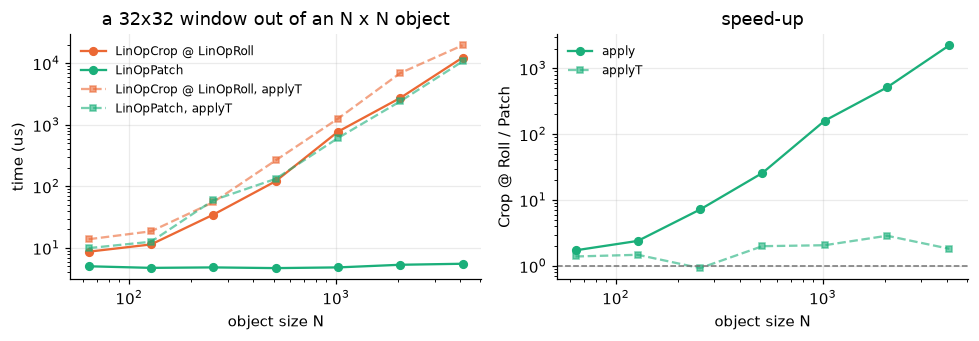

In [7]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax.loglog(sizes_p, 1e6 * np.array(t_roll), "o-", ms=5, color=ORANGE, label="LinOpCrop @ LinOpRoll")
ax.loglog(sizes_p, 1e6 * np.array(t_patch), "o-", ms=5, color=AQUA, label="LinOpPatch")
ax.loglog(sizes_p, 1e6 * np.array(t_rollT), "s--", ms=4, color=ORANGE, alpha=0.6,
          label="LinOpCrop @ LinOpRoll, applyT")
ax.loglog(sizes_p, 1e6 * np.array(t_patchT), "s--", ms=4, color=AQUA, alpha=0.6,
          label="LinOpPatch, applyT")
ax.set(xlabel="object size N", ylabel="time (us)", title=f"a {PATCH}x{PATCH} window out of an N x N object")
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax2.semilogx(sizes_p, np.array(t_roll) / np.array(t_patch), "o-", ms=5, color=AQUA, label="apply")
ax2.semilogx(sizes_p, np.array(t_rollT) / np.array(t_patchT), "s--", ms=4, color=AQUA, alpha=0.6,
             label="applyT")
ax2.axhline(1.0, color="0.45", lw=1, ls="--")
ax2.set(xlabel="object size N", ylabel="Crop @ Roll / Patch", title="speed-up", yscale="log")
ax2.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The forward direction is flat — a few microseconds from a $64^2$ object to a $4096^2$ one, because it reads $32^2$ samples either way — while `Crop @ Roll` pays for a full copy of the object and grows as $N^2$. At $4096^2$ that is three orders of magnitude. The adjoints differ by a constant factor instead: both must produce an $N \times N$ tensor, and the zeroing of that tensor is what they both pay for. For a ptychographic model with thousands of positions, the forward saving is the difference between an hour and a minute.

## A.3 Batching

Batch axes are just leading axes, so a batch is one call on a tensor with one more dimension. The kernels amortise their launch overhead over the batch, so the time *per object* falls until the working set no longer fits in cache.

    B       total    per object
    1     0.03 ms       35.0 us
    2     0.05 ms       23.8 us
    4     0.09 ms       23.0 us
    8     0.15 ms       19.3 us
   16     0.26 ms       16.5 us
   32     0.49 ms       15.2 us
   64     1.02 ms       15.9 us
  128     2.09 ms       16.3 us

per-object cost at B = 128, relative to B = 1: 0.47x


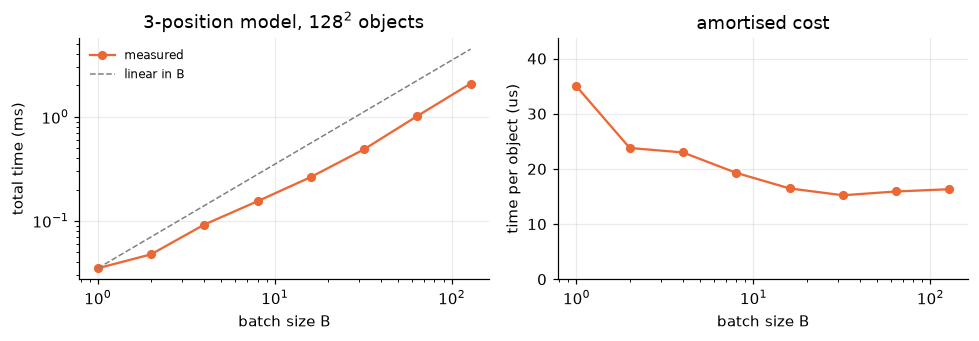

In [8]:
N_BATCH = 128
model = LinOpCat([LinOpFft(dim=(-2, -1)) @ LinOpMul(probe) @ LinOpPatch((N_BATCH, N_BATCH), (PATCH, PATCH),
                                                                       shifts=(s, -s))
                  for s in (-32, 0, 32)])
batches = [1, 2, 4, 8, 16, 32, 64, 128]
t_b = []
print(f"{'B':>5} {'total':>11} {'per object':>13}")
for B in batches:
    xb = torch.randn(B, N_BATCH, N_BATCH, dtype=C64)
    t_b.append(bench(lambda: model.apply(xb), repeats=5))
    print(f"{B:>5} {1e3*t_b[-1]:>8.2f} ms {1e6*t_b[-1]/B:>10.1f} us")
print(f"\nper-object cost at B = {batches[-1]}, relative to B = 1: "
      f"{(t_b[-1]/batches[-1])/t_b[0]:.2f}x")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax.loglog(batches, 1e3 * np.array(t_b), "o-", ms=5, color=ORANGE, label="measured")
ax.loglog(batches, 1e3 * t_b[0] * np.array(batches), "--", color="0.5", lw=1, label="linear in B")
ax.set(xlabel="batch size B", ylabel="total time (ms)", title="3-position model, $128^2$ objects")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax2.semilogx(batches, 1e6 * np.array(t_b) / np.array(batches), "o-", ms=5, color=ORANGE)
ax2.set(xlabel="batch size B", ylabel="time per object (us)", title="amortised cost",
        ylim=(0, 1.25e6 * max(np.array(t_b) / np.array(batches))))
fig.tight_layout()
plt.show()

## A.4 What `to_matrix` costs

`to_matrix(A)` applies the operator to the $n$ basis vectors of its input space in one batched call. The time therefore grows as $n \times \text{cost}(A)$ and the memory as $n \times m$ — for a 2-D operator on an $n \times n$ image that is $n^4$ entries. It is a debugging tool, and the table says where it stops being one.

    image         matrix      memory        time
      4x4        16 x 16     0.00 MiB     0.01 ms
      8x8        64 x 64     0.03 MiB     0.03 ms
    12x12      144 x 144     0.16 MiB     0.09 ms
    16x16      256 x 256     0.50 MiB     0.27 ms
    24x24      576 x 576     2.53 MiB     1.27 ms
    32x32    1024 x 1024     8.00 MiB     3.92 ms
    48x48    2304 x 2304    40.50 MiB    20.24 ms
    64x64    4096 x 4096      0.1 GiB   (do not)
  128x128  16384 x 16384      2.0 GiB   (do not)
  256x256  65536 x 65536     32.0 GiB   (do not)


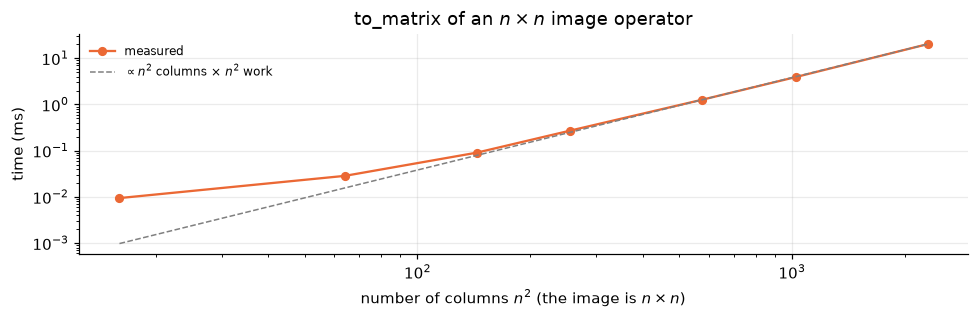

In [9]:
sizes_m = [4, 8, 12, 16, 24, 32, 48]
t_mat, mem_mat = [], []
print(f"{'image':>9} {'matrix':>14} {'memory':>11} {'time':>11}")
for n in sizes_m:
    Am = LinOpFft(dim=(-2, -1)) @ LinOpMul(torch.randn(n, n, dtype=C64))
    t_mat.append(bench(lambda: to_matrix(Am, in_shape=(n, n)), repeats=3))
    mem_mat.append((n * n) ** 2 * 8 / 2 ** 20)
    print(f"{f'{n}x{n}':>9} {f'{n*n} x {n*n}':>14} {mem_mat[-1]:>8.2f} MiB {1e3*t_mat[-1]:>8.2f} ms")
for n in (64, 128, 256):
    print(f"{f'{n}x{n}':>9} {f'{n*n} x {n*n}':>14} {(n*n)**2*8/2**30:>8.1f} GiB   (do not)")

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.loglog(np.array(sizes_m) ** 2, 1e3 * np.array(t_mat), "o-", ms=5, color=ORANGE, label="measured")
ref = 1e3 * t_mat[-1] * (np.array(sizes_m) ** 2 / sizes_m[-1] ** 2) ** 2
ax.loglog(np.array(sizes_m) ** 2, ref, "--", color="0.5", lw=1, label="$\\propto n^2$ columns $\\times$ $n^2$ work")
ax.set(xlabel="number of columns $n^2$ (the image is $n \\times n$)", ylabel="time (ms)",
       title="to_matrix of an $n \\times n$ image operator")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

## A.5 MPS

The operators hold no device: the coefficients you pass in and the tensor you apply them to decide where the work happens, and `LinOpPatch` builds one index table per device it sees. The same model, CPU against Metal, in complex64.

  128x128   CPU    0.09 ms   MPS    0.42 ms   speed-up  0.21   max |cpu - mps| = 1.03e-06
  256x256   CPU    0.34 ms   MPS    0.60 ms   speed-up  0.57   max |cpu - mps| = 1.24e-06
  512x512   CPU    1.13 ms   MPS    1.03 ms   speed-up  1.10   max |cpu - mps| = 2.31e-06


 1024x1024  CPU    5.34 ms   MPS    1.86 ms   speed-up  2.87   max |cpu - mps| = 1.70e-06

adjoint_error on MPS: 2.33e-10


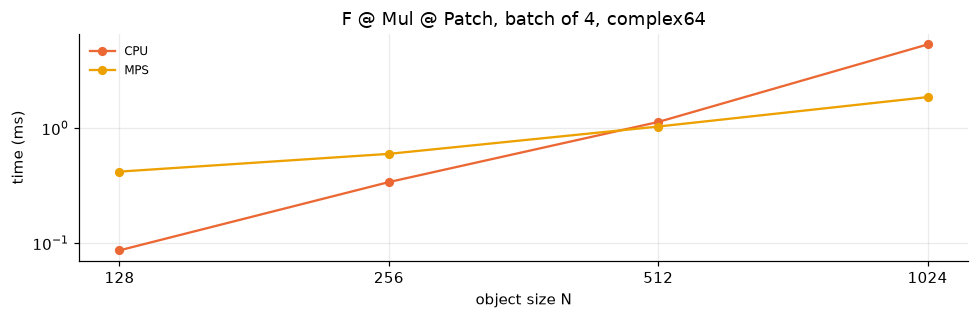

In [10]:
mps_sizes, t_cpu_d, t_mps_d = [], [], []
if torch.backends.mps.is_available():
    try:
        for n in [128, 256, 512, 1024]:
            p_cpu = torch.randn(n // 2, n // 2, dtype=C64)
            chain = lambda p, n=n: (LinOpFft(dim=(-2, -1)) @ LinOpMul(p)
                                    @ LinOpPatch((n, n), (n // 2, n // 2), shifts=(5, -7)))
            A_cpu, A_mps = chain(p_cpu), chain(p_cpu.to("mps"))
            xc = torch.randn(4, n, n, dtype=C64)
            xm = xc.to("mps")
            torch.mps.synchronize()
            tc, tg = bench(lambda: A_cpu.apply(xc), 5), bench(lambda: A_mps.apply(xm), 5)
            e = (A_cpu.apply(xc) - A_mps.apply(xm).cpu()).abs().max().item()
            mps_sizes.append(n); t_cpu_d.append(tc); t_mps_d.append(tg)
            print(f"{n:>5}x{n:<5} CPU {1e3*tc:>7.2f} ms   MPS {1e3*tg:>7.2f} ms   "
                  f"speed-up {tc/tg:>5.2f}   max |cpu - mps| = {e:.2e}")
        print(f"\nadjoint_error on MPS: "
              f"{adjoint_error(A_mps, xm, torch.randn(4, 512, 512, dtype=C64).to('mps')):.2e}")
    except Exception as exc:                          # pragma: no cover - device dependent
        print("MPS run failed:", type(exc).__name__, exc)
else:
    print("MPS is not available on this machine.")

if mps_sizes:
    fig, ax = plt.subplots(figsize=(9, 3.0))
    ax.loglog(mps_sizes, 1e3 * np.array(t_cpu_d), "o-", ms=5, color=ORANGE, label="CPU")
    ax.loglog(mps_sizes, 1e3 * np.array(t_mps_d), "o-", ms=5, color=YELLOW, label="MPS")
    ax.set(xlabel="object size N", ylabel="time (ms)", title="F @ Mul @ Patch, batch of 4, complex64")
    ax.set_xticks(mps_sizes, [str(v) for v in mps_sizes])
    ax.minorticks_off()
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    plt.show()

# Part B — Precision

## B.1 How exact is "exact"?

The adjoint identity $\langle Ax, y\rangle = \langle x, A^H y\rangle$ holds for the mathematical operator; what the code computes is subject to round-off, so `adjoint_error` returns a small number rather than zero. Below, the composed model $\mathcal{F}\,p\,\mathrm{crop}$ in complex64 and complex128, against size, five random draws per point.

Each point is the worst of five random draws. The error *falls* with $N$, which is the normalisation at work: the discrepancy accumulates like $\sqrt{N}\,\varepsilon$ over the sum, while the denominator $\lVert Ax\rVert\lVert y\rVert$ grows like $N$, so the ratio goes as $\varepsilon/\sqrt{N}$. What matters is the gap between the two dtypes — some eight orders of magnitude, the ratio $\varepsilon_{32}/\varepsilon_{64}$ — and that neither drifts with size.

     N    complex64    complex128
    16     8.90e-09      2.89e-17
    32     5.45e-09      7.08e-18
    64     5.49e-09      8.76e-18
   128     3.30e-09      6.92e-18
   256     6.97e-10      1.30e-18


   512     5.84e-10      1.30e-18


  1024     2.33e-10      4.33e-19

ratio, median over the sweep: 5.4e+08   (eps32 / eps64 = 5.4e+08)
worst over the sweep: complex64 8.9e-09, complex128 2.9e-17


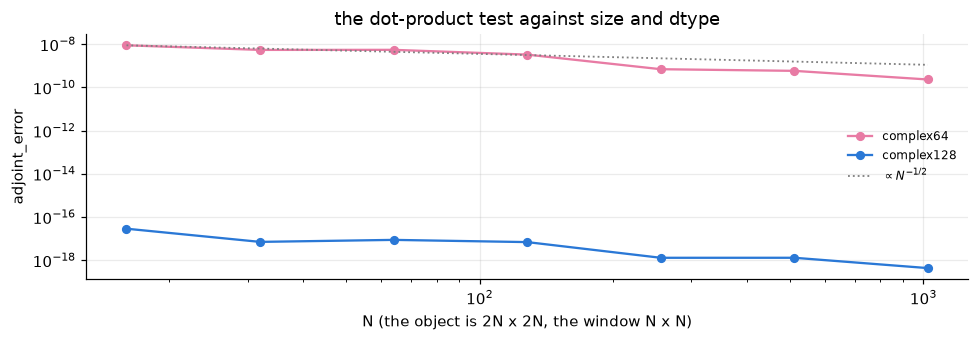

In [11]:
sizes_e = [16, 32, 64, 128, 256, 512, 1024]
e32, e64 = [], []
print(f"{'N':>6} {'complex64':>12} {'complex128':>13}")
for n in sizes_e:
    row = []
    for dtype in (C64, C128):
        Ae = (LinOpFft(dim=(-2, -1)) @ LinOpMul(torch.randn(n, n, dtype=dtype))
              @ LinOpCrop((2 * n, 2 * n), (n, n)))
        row.append(max(adjoint_error(Ae, torch.randn(2 * n, 2 * n, dtype=dtype),
                                     torch.randn(n, n, dtype=dtype)) for _ in range(5)))
    e32.append(row[0]); e64.append(row[1])
    print(f"{n:>6} {row[0]:>12.2e} {row[1]:>13.2e}")
print(f"\nratio, median over the sweep: {np.median(np.array(e32) / np.array(e64)):.1e}"
      f"   (eps32 / eps64 = {np.finfo(np.float32).eps / np.finfo(np.float64).eps:.1e})")
print(f"worst over the sweep: complex64 {max(e32):.1e}, complex128 {max(e64):.1e}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.loglog(sizes_e, e32, "o-", ms=5, color=PINK, label="complex64")
ax.loglog(sizes_e, e64, "o-", ms=5, color=BLUE, label="complex128")
ax.loglog(sizes_e, np.array(e32)[0] * (np.array(sizes_e) / sizes_e[0]) ** -0.5, ":", color="0.5",
          lw=1.2, label=r"$\propto N^{-1/2}$")
ax.set(xlabel="N (the object is 2N x 2N, the window N x N)",
       ylabel="adjoint_error", title="the dot-product test against size and dtype")
ax.legend(frameon=False, fontsize=8, loc="center right", ncols=1)
fig.tight_layout()
plt.show()

## B.2 Where float32 is not enough

An exact adjoint does not make a *solver* exact. The gradient iteration of notebook 1, run in both precisions with the step $1/\lVert A\rVert^2$ that `operator_norm` gives, stalls when the residual reaches the round-off floor of its dtype and no number of extra iterations moves it. Everything else about the two runs is identical, and the cost of float64 here is about 20%.

In [12]:
n, WIN = 64, 24
shifts_b = [(sy, sx) for sy in (-24, -8, 8, 24) for sx in (-24, -8, 8, 24)]
gp = torch.arange(WIN, dtype=torch.float64) - WIN // 2
r2 = (gp[:, None] ** 2 + gp[None, :] ** 2) / (WIN / 2) ** 2
probe_b = torch.exp(-1.5 * r2 ** 2) * torch.exp(1j * 5.0 * r2)      # the probe of notebook 1

print(f"{'dtype':>12} {'20 it.':>10} {'40 it.':>10} {'150 it.':>10} {'error on x':>12} {'time':>9}")
for dtype in (C64, C128):
    Ab = LinOpCat([LinOpFft(dim=(-2, -1)) @ LinOpMul(probe_b.to(dtype))
                   @ LinOpPatch((n, n), (WIN, WIN), shifts=s) for s in shifts_b])
    x_true = torch.randn(n, n, dtype=dtype)
    bb = Ab @ x_true
    tau_b = 1.0 / operator_norm(Ab, torch.randn(n, n, dtype=dtype), n_iter=60) ** 2
    scale = float((bb.abs() ** 2).sum())
    xx, hist = torch.zeros(n, n, dtype=dtype), []
    t0 = time.perf_counter()
    for _ in range(150):
        r = Ab @ xx - bb
        hist.append(float((r.abs() ** 2).sum()) / scale)
        xx = xx - tau_b * (Ab.H @ r)
    dt = time.perf_counter() - t0
    print(f"{str(dtype).split('.')[-1]:>12} {hist[20]:>10.1e} {hist[40]:>10.1e} {hist[-1]:>10.1e} "
          f"{float((xx - x_true).norm() / x_true.norm()):>12.1e} {1e3*dt:>6.0f} ms")

       dtype     20 it.     40 it.    150 it.   error on x      time
   complex64    1.5e-10    1.7e-14    1.7e-14      9.7e-08     69 ms


  complex128    1.3e-10    4.0e-18    6.1e-32      1.8e-16     82 ms


# Part C — When not to use it

## C.1 When the arrays are tiny

The dispatch cost measured in A.1 — well under a microsecond for a three-operator chain — is invisible next to a $128^2$ FFT and is *not* invisible next to a $4 \times 4$ one. Below, the same chain on a shrinking problem: the share of the time spent in Python rather than in `torch` grows to a fifth. Nothing here is a reason to avoid the library, but it does mean that wrapping a handful of numbers in an operator tree, in an inner loop, buys nothing.

In [13]:
print(f"{'window':>8} {'operator':>11} {'by hand':>11} {'overhead':>11} {'share':>8}")
for m in (4, 8, 16, 32, 64, 128):
    p = torch.randn(m, m, dtype=C64)
    Ac = LinOpFft(dim=(-2, -1)) @ LinOpMul(p) @ LinOpCrop((2 * m, 2 * m), (m, m))
    xc = torch.randn(2 * m, 2 * m, dtype=C64)
    lo = m // 2
    handc = lambda: torch.fft.fft2(p * xc[lo:lo + m, lo:lo + m], norm="ortho")
    to, th = bench(lambda: Ac.apply(xc), 21), bench(handc, 21)
    print(f"{f'{m}x{m}':>8} {1e6*to:>8.2f} us {1e6*th:>8.2f} us {1e6*(to-th):>+8.2f} us "
          f"{100*(to-th)/to:>7.1f}%")

  window    operator     by hand    overhead    share
     4x4     4.75 us     3.67 us    +1.08 us    22.8%
     8x8     4.75 us     3.88 us    +0.88 us    18.4%
   16x16     5.25 us     4.54 us    +0.71 us    13.5%
   32x32     6.79 us     6.04 us    +0.75 us    11.0%
   64x64    14.12 us    13.37 us    +0.75 us     5.3%
 128x128    53.17 us    52.13 us    +1.04 us     2.0%


## C.2 The other limits

* **A dense matrix that fits in memory is better as a tensor.** `LinOpMatrix` exists so that a measurement matrix can join a chain, not to beat `M @ x`; for a plain matrix–vector product, write `M @ x`.
* **`to_matrix` is $O(n \cdot \text{cost}(A))$ in time and $O(nm)$ in memory.** A.4 puts $48 \times 48$ images at 42 MiB and a tenth of a second; $256 \times 256$ would be 32 TiB. Use it on a shrunken version of your operator.
* **`operator_norm` costs `n_iter` forward *and* adjoint applications** and converges from below; for a step size, compute it once and cache it, and keep a margin.
* **`LinOpCat` concatenates along the last axis only**, so a model with heterogeneous outputs has to be flattened into that axis. Mixed shapes are a `LinOpFunction` away, but the library will not do it for you.
* **Nothing here is nonlinear.** $y = |Ax|^2$ is not a `LinOp`; it is a model *built on* one, which is what [minimal-phase-retrieval](https://github.com/jon-dong/minimal-phase-retrieval) does with these operators.
* **The catalogue is closed by design.** A propagation kernel, a convolution, a wavelet transform: write the two methods, check `adjoint_error`, and compose. That is the whole extension mechanism, and the README's *Write your own* is five lines long.

## Summary

In [14]:
print(f"composition overhead vs hand-written torch : {1e6*(t_op[2]-t_hand[2]):+.2f} us at "
      f"{sizes_ov[2]}x{sizes_ov[2]}, {per_node:.0f} ns per operator in the chain")
print(f"LinOpPatch vs LinOpCrop @ LinOpRoll        : {t_roll[-1]/t_patch[-1]:.0f}x forward at "
      f"{sizes_p[-1]}x{sizes_p[-1]}, {t_rollT[-1]/t_patchT[-1]:.1f}x adjoint")
print(f"batching, per-object cost B=1 -> B={batches[-1]:<4}    : "
      f"{1e6*t_b[0]:.1f} us -> {1e6*t_b[-1]/batches[-1]:.1f} us")
print(f"to_matrix, 32x32 image operator            : {1e3*t_mat[sizes_m.index(32)]:.1f} ms, "
      f"{mem_mat[sizes_m.index(32)]:.0f} MiB")
if mps_sizes:
    print(f"{f'MPS vs CPU at {mps_sizes[-1]}x{mps_sizes[-1]}':<42s} : "
          f"{t_cpu_d[-1]/t_mps_d[-1]:.2f}x, agreeing to float32 round-off")
print(f"adjoint_error, complex64 / complex128      : {np.median(e32):.1e} / {np.median(e64):.1e}")

composition overhead vs hand-written torch : +1.04 us at 256x256, 36 ns per operator in the chain
LinOpPatch vs LinOpCrop @ LinOpRoll        : 2241x forward at 4096x4096, 1.8x adjoint
batching, per-object cost B=1 -> B=128     : 35.0 us -> 16.3 us
to_matrix, 32x32 image operator            : 3.9 ms, 8 MiB
MPS vs CPU at 1024x1024                    : 2.87x, agreeing to float32 round-off
adjoint_error, complex64 / complex128      : 3.3e-09 / 6.9e-18


* **The algebra is free.** A composed operator costs what the same three `torch` calls cost; the tree adds well under a microsecond, and a few tens of nanoseconds per extra node, which matters only when the arrays themselves are a few hundred elements (C.1).
* **The operators that are specialised are worth it.** `LinOpPatch` is flat in the object size where `LinOpCrop @ LinOpRoll` grows as $N^2$ — three orders of magnitude at $4096^2$ — and both compute the same numbers, bit for bit.
* **Batching amortises.** Per object, a batch of 128 is several times cheaper than one call at a time, on the same code.
* **`to_matrix` is a debugging tool**, quartic in the image size; `operator_norm` costs iterations of $A$ and $A^H$.
* **Precision follows the dtype and nothing else**: the dot-product test sits at $\varepsilon/\sqrt{N}$ in both complex64 and complex128, nine orders of magnitude apart, over six decades of size.

**Back to the start.** [Notebook 1](01_why_linear_operators.ipynb) is the argument for operators — the gradient of a reconstruction is an adjoint, and a wrong one is silent until the solver diverges. [Notebook 2](02_what_it_computes.ipynb) is the specification: every identity, every adjoint, every convention, checked. The [README](../README.md) is the one-screen version of both, and `tests/` runs all of it on every commit.